In [1]:
# import packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import math
from mpl_toolkits.axes_grid1 import Divider, Size
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM
import statsmodels.api as sm
from statsmodels.tsa.stattools import pacf, acf, adfuller
import statsmodels.tsa.api as tsa

Text(0.5, 1.0, 'Predicted Sentiment of Presidential Candidates, 2004-2024')

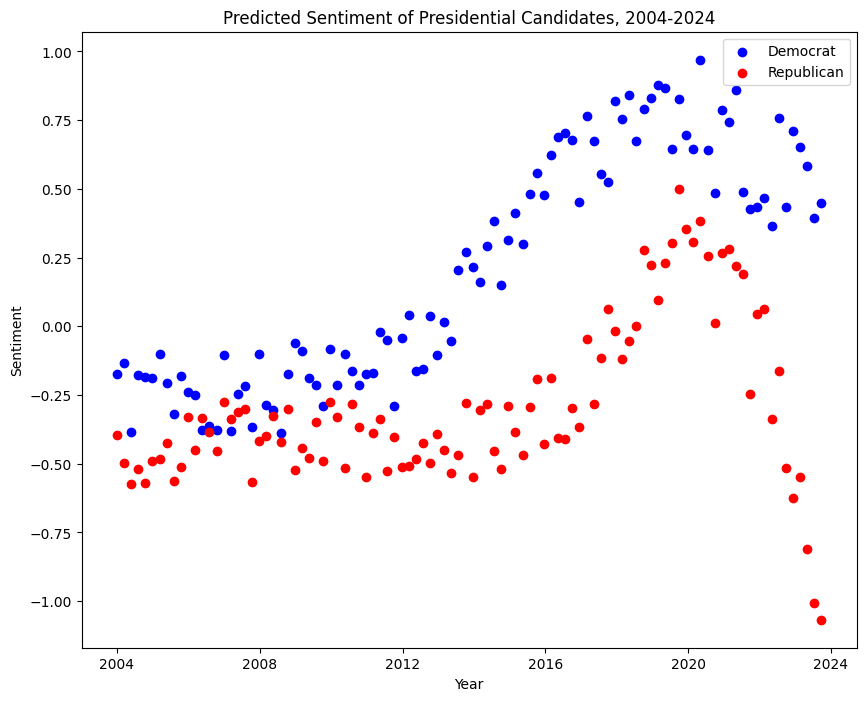

In [2]:
# graph the expected shape of the data

fig, ax = plt.subplots(1,1, figsize=(10, 8))

x = list(range(0, 100))
x = [float(a)*0.1 for a in x]
y1 = [-0.4 + 1 / (1 + math.e **(8 - 1.5*a)) + random.random()*0.33 for a in x[:80]]
y2 = [0.5 - (1/8)*(a-8)**2 + random.random()*0.5 for a in x[80:]]
y = y1 + y2
x = [pd.Timedelta(weeks=a*104)+pd.Timestamp('2004-1-1') for a in x]

plt.scatter(x, y, c='blue', label='Democrat')

x = list(range(0, 100))
x = [float(a)*0.1 for a in x]
y1 = [-0.6 + 1 / (1 + math.e **(13 - 1.8*a)) + random.random()*0.33 for a in x[:80]]
y2 = [- 0.33*(a-8)**2 + random.random()*0.5 for a in x[80:]]
y = y1 + y2
x = [pd.Timedelta(weeks=a*104)+pd.Timestamp('2004-1-1') for a in x]

plt.scatter(x, y, c='red', label='Republican')

plt.xlabel('Year')
plt.ylabel('Sentiment')
plt.legend()
plt.title('Predicted Sentiment of Presidential Candidates, 2004-2024')

In [3]:
# define column names to keep and sort candidates by party

keep = ['Date', 'TRUMP', 'HARRIS', 'BIDEN', 'CLINTON', 'OBAMA', 'ROMNEY', 'MCCAIN', 'KERRY', 'BUSH']
R = ["TRUMP", "ROMNEY", "MCCAIN", "BUSH"]
D = ["HARRIS", "BIDEN", "CLINTON", "OBAMA", "KERRY"]

In [4]:
# load csvs, delete unnecessary data, sort candidates by party into two dataframes

debates = pd.read_csv("debates.csv")
speeches = pd.read_csv("speeches.csv")
tweets = pd.read_csv("tweets.csv")
csvs = [debates, speeches, tweets]

for csv in csvs:
  csv.rename(columns={"Unnamed: 0": "Date"}, inplace=True)
  csv.set_index("Date", inplace=True)
  for col in csv.columns:
    if col not in keep:
      csv.pop(col)
    if col in R:
      csv.rename(columns={col: "REPUBLICAN"}, inplace=True)
    if col in D:
      csv.rename(columns={col: "DEMOCRAT"}, inplace=True)

time_series = pd.concat(csvs, axis=1)
time_series = time_series.groupby(axis=1, level=0).sum(min_count=1)
time_series.drop("2000-03-07", inplace=True)
time_series.index = pd.to_datetime(time_series.index)
DEMOCRAT = pd.DataFrame(time_series["DEMOCRAT"])
DEMOCRAT.dropna(inplace=True)
DEMOCRAT["Party"] = "DEMOCRAT"
DEMOCRAT["Color"] = "blue"
DEMOCRAT["Sentiment"] = DEMOCRAT["DEMOCRAT"]
DEMOCRAT.pop("DEMOCRAT")
REPUBLICAN = pd.DataFrame(time_series["REPUBLICAN"])
REPUBLICAN.dropna(inplace=True)
REPUBLICAN["Party"] = "REPUBLICAN"
REPUBLICAN["Color"] = "red"
REPUBLICAN["Sentiment"] = REPUBLICAN["REPUBLICAN"]
REPUBLICAN.pop("REPUBLICAN")

<ipython-input-4-c83ea1dbc616>:20: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  time_series = time_series.groupby(axis=1, level=0).sum(min_count=1)


,REPUBLICAN
Date,
2016-10-19,-1.0
2024-09-10,-0.8
2004-10-13,-0.6
2004-09-02,0.3
2008-04-22,0.0
...,...
2023-05-07,0.0
2023-03-02,-0.8
2023-02-15,-0.8


In [5]:
time_series = pd.concat([DEMOCRAT, REPUBLICAN])
time_series

,Party,Color,Sentiment
Date,,,
2016-10-19,DEMOCRAT,blue,1.0
2024-09-10,DEMOCRAT,blue,0.5
2016-10-09,DEMOCRAT,blue,-0.8
2012-10-03,DEMOCRAT,blue,0.0
2004-10-13,DEMOCRAT,blue,-0.5
...,...,...,...
2023-05-07,REPUBLICAN,red,0.0
2023-03-02,REPUBLICAN,red,-0.8
2023-02-15,REPUBLICAN,red,-0.8


In [6]:
# print the size of the dataset

print(len(time_series))
print(len(REPUBLICAN))
print(len(DEMOCRAT))

398
91
307


In [7]:
# calculate summary statistics

print(round(time_series["Sentiment"].mean(), 2))
print(round(time_series["Sentiment"].std(), 2))
print(round(DEMOCRAT["Sentiment"].mean(), 2))
print(round(DEMOCRAT["Sentiment"].std(), 2))
print(round(REPUBLICAN["Sentiment"].mean(), 2))
print(round(REPUBLICAN["Sentiment"].std(), 2))

0.47
0.72
0.7
0.6
-0.33
0.51


Text(0.5, 1.0, 'Distribution of Republican Sentiment')

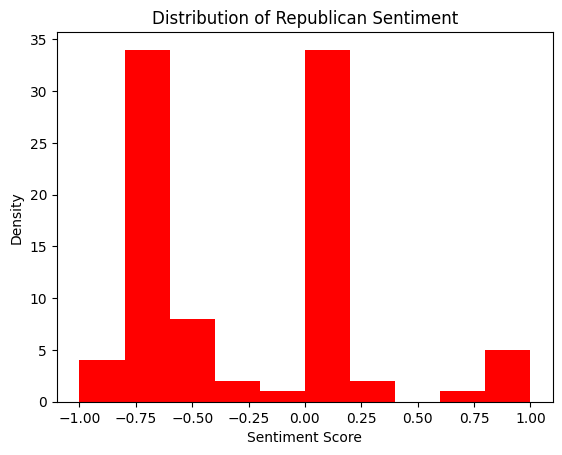

In [8]:
plt.hist(REPUBLICAN['Sentiment'], color='red')
plt.xlabel("Sentiment Score")
plt.ylabel("Density")
plt.title("Distribution of Republican Sentiment")

Text(0.5, 1.0, 'Distribution of Democratic Sentiment')

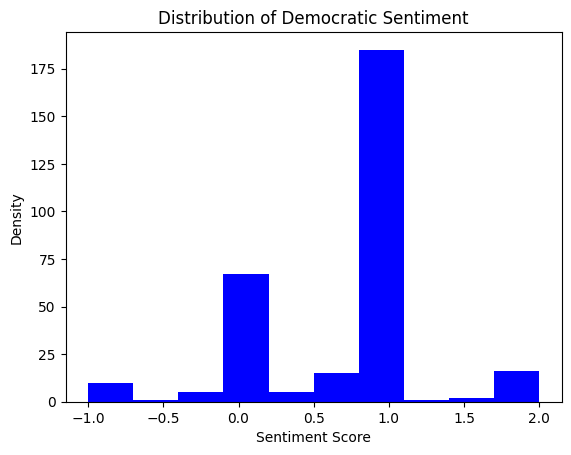

In [9]:
plt.hist(DEMOCRAT['Sentiment'], color='blue')
plt.xlabel("Sentiment Score")
plt.ylabel("Density")
plt.title("Distribution of Democratic Sentiment")

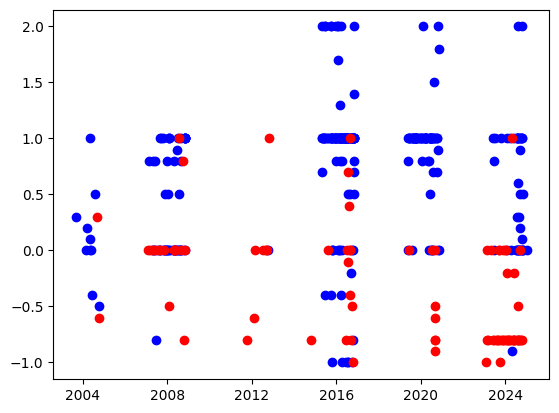

In [10]:
plt.scatter(y=DEMOCRAT['Sentiment'], x=DEMOCRAT.index, c='blue')
plt.scatter(y=REPUBLICAN['Sentiment'], x=REPUBLICAN.index, c='red')

In [11]:
# some preliminary processing required for the RNN model. From each party, make an array of X values from the first

def create_dataset(data):
  time_step=int(len(data)/4)
  X, y = [], []
  for i in range(len(data) - time_step):
    X.append(data[i:(i + time_step), 0])
    y.append(data[i + time_step, 0])
  return np.array(X), np.array(y)

R = REPUBLICAN["Sentiment"].values.reshape(-1, 1)
X_R, y_R = create_dataset(R)
X_R = X_R.reshape(X_R.shape[0], X_R.shape[1], 1)

D = DEMOCRAT["Sentiment"].values.reshape(-1, 1)
X_D, y_D = create_dataset(D)
X_D = X_D.reshape(X_D.shape[0], X_D.shape[1], 1)

X_R = X_R.reshape(X_R.shape[0], X_R.shape[1], 1)
X_D = X_D.reshape(X_D.shape[0], X_D.shape[1], 1)

In [12]:
# create training and testing data sets

X_R_train, X_R_test, y_R_train, y_R_test = train_test_split(X_R, y_R, train_size=0.8, random_state=3)
X_D_train, X_D_test, y_D_train, y_D_test = train_test_split(X_D, y_D, train_size=0.8, random_state=3)
"""X_R_train = X_R[:int(len(X_R)*0.8)]
X_R_test = X_R[int(len(X_R)*0.8):]
y_R_train = y_R[:int(len(y_R)*0.8)]
y_R_test = y_R[int(len(y_R)*0.8):]
X_D_train = X_D[:int(len(X_D)*0.8)]
X_D_test = X_D[int(len(X_D)*0.8):]
y_D_train = y_D[:int(len(y_D)*0.8)]
y_D_test = y_D[int(len(y_D)*0.8):]"""

'X_R_train = X_R[:int(len(X_R)*0.8)]\nX_R_test = X_R[int(len(X_R)*0.8):]\ny_R_train = y_R[:int(len(y_R)*0.8)]\ny_R_test = y_R[int(len(y_R)*0.8):]\nX_D_train = X_D[:int(len(X_D)*0.8)]\nX_D_test = X_D[int(len(X_D)*0.8):]\ny_D_train = y_D[:int(len(y_D)*0.8)]\ny_D_test = y_D[int(len(y_D)*0.8):]'

In [13]:
# train the models

model_R = Sequential()
model_R.add(SimpleRNN(units=60, return_sequences=True, activation='relu', input_shape=(X_R_train.shape[1], 1)))
model_R.add(SimpleRNN(units=100, activation='relu', return_sequences=False))
model_R.add(Dense(units=1, activation='linear'))
model_R.compile(optimizer='adam', loss='mean_squared_error', metrics=["r2_score"])

model_D = Sequential()
model_D.add(SimpleRNN(units=75, return_sequences=True, activation='relu', input_shape=(X_D_train.shape[1], 1)))
model_D.add(SimpleRNN(units=20, activation='relu', return_sequences=False))
model_D.add(Dense(units=1, activation='linear'))
model_D.compile(optimizer='adam', loss='mean_squared_error', metrics=["r2_score"])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
# use the model to predict the sentiment of the trest datasets
# due to the random nature of neural networks, resulta will vary

model_R.fit(X_R_train, y_R_train, epochs=20, batch_size=64)
predictions_R_test = model_R.predict(X_R_test)

model_D.fit(X_D_train, y_D_train, epochs=20, batch_size=64)
predictions_D_test = model_D.predict(X_D_test)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - loss: 0.3896 - r2_score: -0.8555
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - loss: 0.3201 - r2_score: -0.5246
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.2615 - r2_score: -0.2455
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.2144 - r2_score: -0.0213
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 0.1816 - r2_score: 0.1350
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.1807 - r2_score: 0.1396
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - loss: 0.1976 - r2_score: 0.0590
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 0.1927 - r2_score: 0.0824
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.1776 - r2_score: 0.1540
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.1661 - r2_score: 0.2091
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.1604 - r2_score: 0.2362
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.1589 - r2_score: 0

In [15]:
# calculate the loss for each of the models
# results will vary

loss_R, R2_R = model_R.evaluate(X_R_test, y_R_test)
loss_D, R2_D = model_D.evaluate(X_D_test, y_D_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - loss: 0.2996 - r2_score: 0.1466
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.4095 - r2_score: -0.1917 


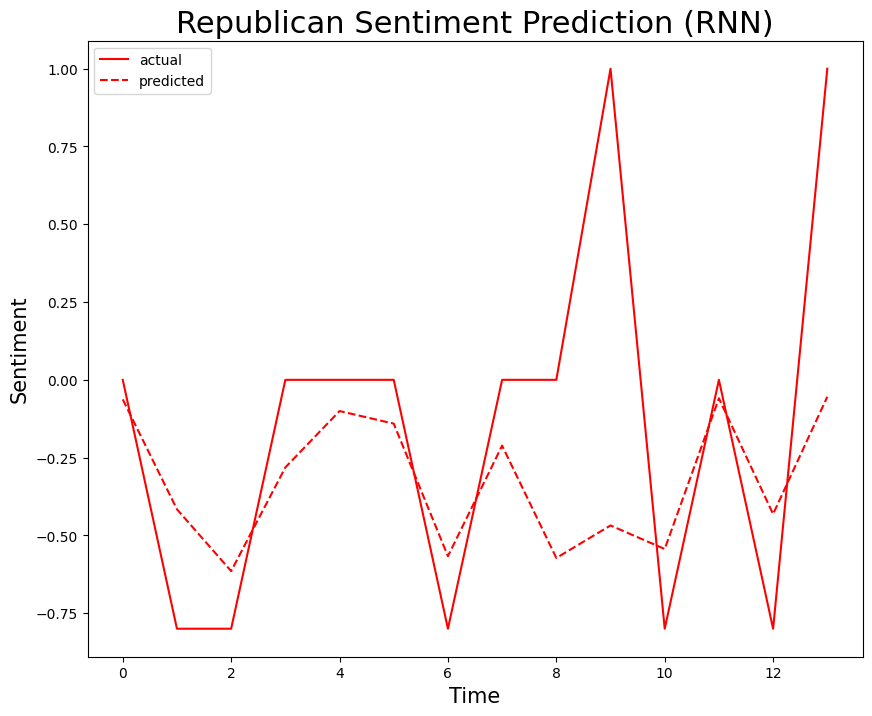

In [16]:
# plot actual vs predicted sentiment on the Republican test dataset
# results will vary

fig, ax = plt.subplots(1,1, figsize=(10, 8))
ax.plot(y_R_test.reshape(-1, 1), color='red', label='actual')
ax.plot(predictions_R_test, color='red', linestyle="dashed", label='predicted')
ax.set_title(f'Republican Sentiment Prediction (RNN)', fontsize=22)
plt.xlabel('Time', fontsize=15)
plt.ylabel('Sentiment', fontsize=15)
plt.legend()
#plt.savefig("rep_sent.png")
#plt.close()

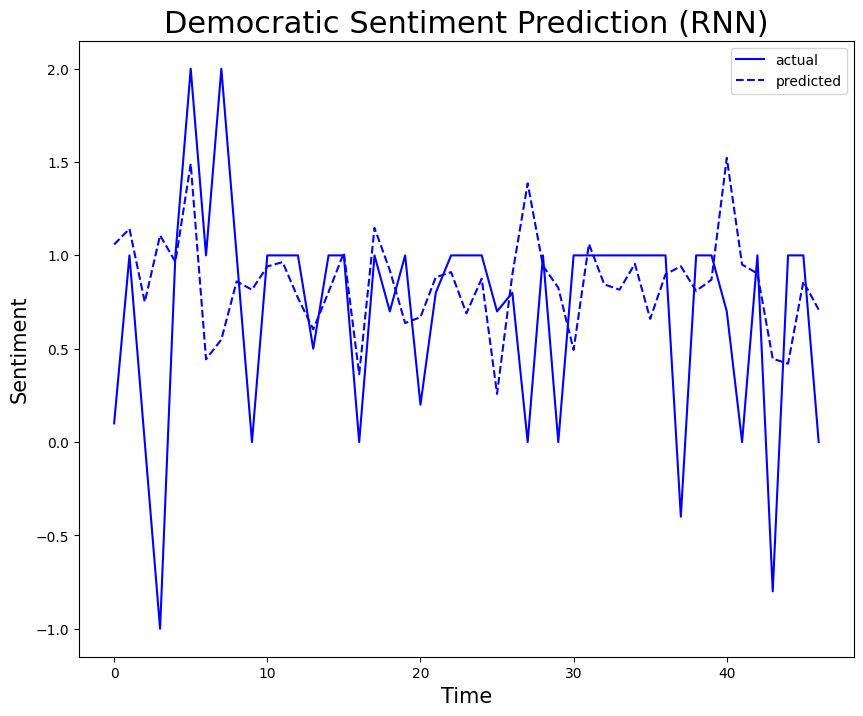

In [17]:
# plot actual vs predicted sentiment on the Democratic test dataset
# results will vary

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.plot(y_D_test.reshape(-1, 1), color='blue', label='actual')
ax.plot(predictions_D_test, color='blue', linestyle="dashed", label='predicted')
plt.title(f'Democratic Sentiment Prediction (RNN)', fontsize=22)
plt.xlabel('Time', fontsize=15)
plt.ylabel('Sentiment', fontsize=15)
plt.legend()
#plt.savefig("dem_sent.png")
#plt.close()

In [18]:
# make predictions for the whole dataset
# results will vary

predict_R_RNN = model_R.predict(R.reshape(R.shape[0], R.shape[1], 1))
predict_D_RNN = model_D.predict(D.reshape(D.shape[0], D.shape[1], 1))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step 


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  


In [19]:
# split the dataset into training and testing subsets for the ARIMA model

train_D, test_D = train_test_split(time_series[time_series['Party']=='DEMOCRAT'], train_size=0.8, random_state=3)
train_R, test_R = train_test_split(time_series[time_series['Party']=='REPUBLICAN'], train_size=0.8, random_state=3)
"""X_R = time_series[time_series['Party']=='REPUBLICAN']
X_D = time_series[time_series['Party']=='DEMOCRAT']
train_R = X_R[:int(len(X_R)*0.8)]
test_R = X_R[int(len(X_R)*0.8):]
train_D = X_D[:int(len(X_D)*0.8)]
test_D = X_D[int(len(X_D)*0.8):]"""

"X_R = time_series[time_series['Party']=='REPUBLICAN']\nX_D = time_series[time_series['Party']=='DEMOCRAT']\ntrain_R = X_R[:int(len(X_R)*0.8)]\ntest_R = X_R[int(len(X_R)*0.8):]\ntrain_D = X_D[:int(len(X_D)*0.8)]\ntest_D = X_D[int(len(X_D)*0.8):]"

In [20]:
# check for stationarity; if any results come back negative we will have to difference the data

statr = adfuller(train_R['Sentiment'])
print("Stationary? ", statr[1] < 0.05)
statd = adfuller(train_D['Sentiment'])
print("Stationary? ", statd[1] < 0.05)

Stationary?  True
Stationary?  True


In [21]:
# a function to calculate R^2

def calc_R2(resids, data):
  rss = 0
  for resid in resids:
    rss += resid**2
  mu = 0
  for item in data:
    mu += item
  mu = mu / len(data)
  tss = 0
  for item in data:
    tss += (item-mu)**2
  R2 = 1 - (rss / tss)
  return R2

In [22]:
# test different models to determine values of p and q for Democrats

best_p = 0
best_q = 0
perf = [0]
for p in range(6):
  for q in range(6):
    arima_model_D = tsa.ARIMA(train_D['Sentiment'], order=(p, 0, q)).fit()
    R2 = calc_R2(arima_model_D.resid, train_D['Sentiment'])
    if R2 > max(perf):
      best_p = p
      best_q = q
    perf.append(R2)
arima_model_D = tsa.ARIMA(train_D['Sentiment'], order=(best_p, 0, best_q)).fit()
R2 = calc_R2(arima_model_D.resid, train_D['Sentiment'])
print("Training R\u00B2: ", round(R2, 4))
print("p: ", best_p)
print("q: ", best_q)

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsm

Training R²:  0.0673
p:  5
q:  4


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [23]:
# do the same as above for Republicans

best_p = 0
best_q = 0
perf = [0]
for p in range(6):
  for q in range(6):
    arima_model_R = tsa.ARIMA(train_R['Sentiment'], order=(p, 0, q)).fit()
    R2 = calc_R2(arima_model_R.resid, train_R['Sentiment'])
    if R2 > max(perf):
      best_p = p
      best_q = q
    perf.append(R2)
arima_model_R = tsa.ARIMA(train_R['Sentiment'], order=(best_p, 0, best_q)).fit()
R2 = calc_R2(arima_model_R.resid, train_R['Sentiment'])
print("Training R\u00B2: ", round(R2, 4))
print("p: ", best_p)
print("q: ", best_q)

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsm

Training R²:  0.0749
p:  4
q:  5


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [24]:
# test the model on the test data sets

test_D.sort_index(inplace=True)
test_D.reset_index(inplace=True)
test_R.sort_index(inplace=True)
test_R.reset_index(inplace=True)

forecast_D = arima_model_D.predict(start=test_D.index.min(), end=test_D.index.max())
forecast_D = forecast_D.reset_index()
residsD = forecast_D['predicted_mean'] - test_D['Sentiment']
R2 = calc_R2(residsD, test_D['Sentiment'])
print("R\u00B2 (D): ", round(R2, 4))

forecast_R = arima_model_R.predict(start=test_R.index.min(), end=test_R.index.max())
forecast_R = forecast_R.reset_index()
residsR = forecast_R['predicted_mean'] - test_R['Sentiment']
R2 = calc_R2(residsR, test_R['Sentiment'])
print("R\u00B2 (R): ", round(R2, 4))

R² (D):  -0.0007
R² (R):  0.0413


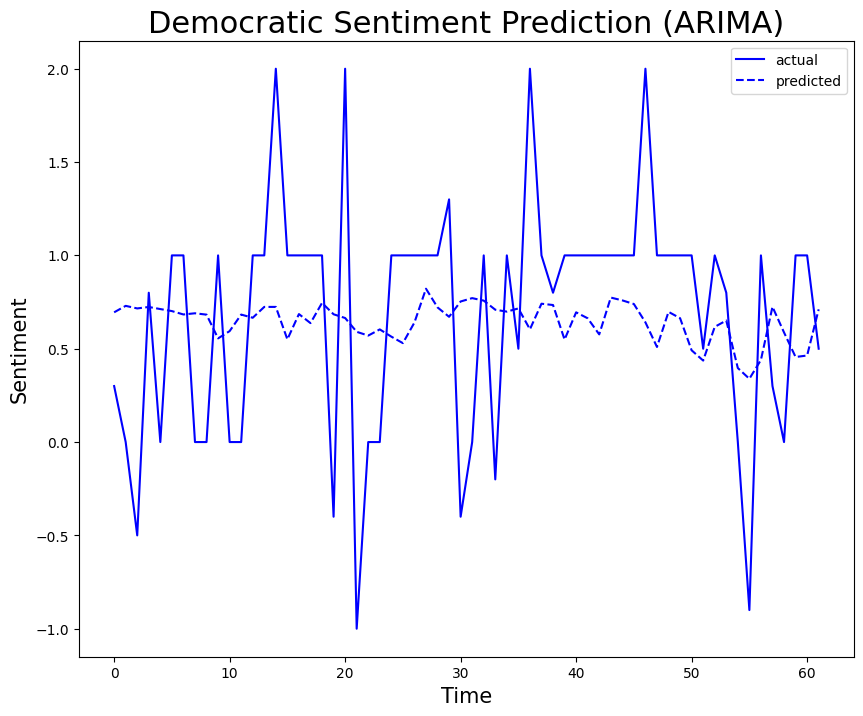

In [25]:
# plot the ARIMA predictions

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.plot(test_D['Sentiment'], color='blue', label='actual')
ax.plot(forecast_D['predicted_mean'], color='blue', linestyle="dashed", label='predicted')
plt.title(f'Democratic Sentiment Prediction (ARIMA)', fontsize=22)
plt.xlabel('Time', fontsize=15)
plt.ylabel('Sentiment', fontsize=15)
plt.legend()

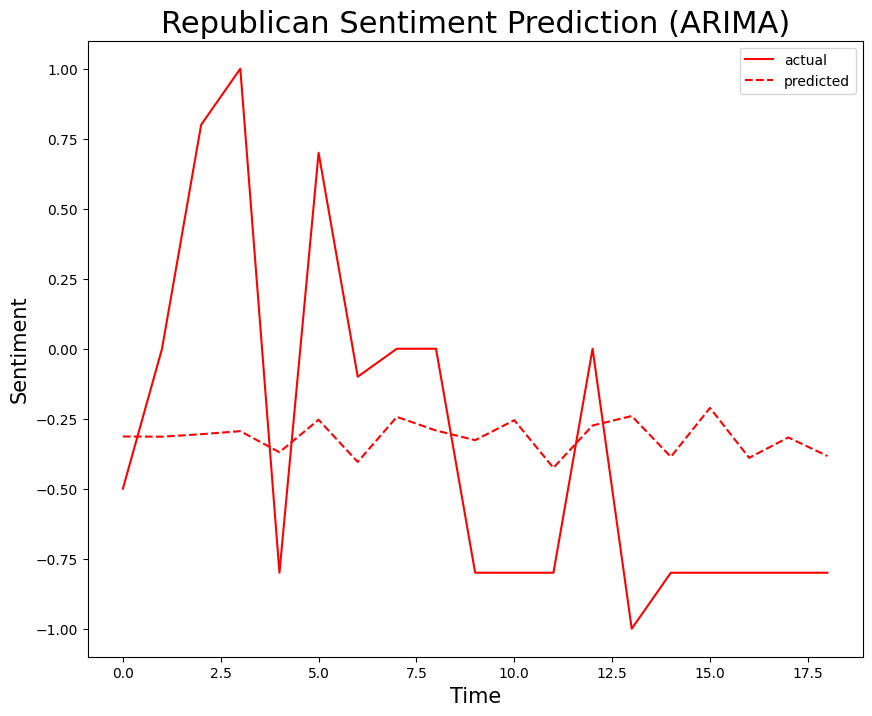

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.plot(test_R.index, test_R['Sentiment'], color='red', label='actual')
ax.plot(forecast_R['predicted_mean'], color='red', linestyle="dashed", label='predicted')
plt.title(f'Republican Sentiment Prediction (ARIMA)', fontsize=22)
plt.xlabel('Time', fontsize=15)
plt.ylabel('Sentiment', fontsize=15)
plt.legend()

In [27]:
# make predictions for the whole dataset and record the results

predict_D_ARIMA = arima_model_D.predict(start=0, end=len(DEMOCRAT)-1)
predict_R_ARIMA = arima_model_D.predict(start=0, end=len(REPUBLICAN)-1)

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [28]:
DEMOCRAT.sort_index(inplace=True)
REPUBLICAN.sort_index(inplace=True)

In [29]:
# combine the two dataframes into one and set the color for the plots

time_series = pd.concat([DEMOCRAT, REPUBLICAN])
time_series = time_series.sort_index()
time_series.reset_index(inplace=True)
print(time_series.head())

        Date     Party Color  Sentiment
0 2003-09-02  DEMOCRAT  blue        0.3
1 2004-03-02  DEMOCRAT  blue        0.0
2 2004-03-08  DEMOCRAT  blue        0.2
3 2004-04-30  DEMOCRAT  blue        0.1
4 2004-05-03  DEMOCRAT  blue        1.0


In [47]:
# create training and test subset for the polynomial models

train_D, test_D = train_test_split(time_series[time_series['Party']=='DEMOCRAT'], train_size=0.8, random_state=4)
train_R, test_R = train_test_split(time_series[time_series['Party']=='REPUBLICAN'], train_size=0.8, random_state=4)

train_R = train_R.set_index('Date').sort_index()
train_D = train_D.set_index('Date').sort_index()
test_R = test_R.set_index('Date').sort_index()
test_D = test_D.set_index('Date').sort_index()

In [49]:
# build polynomial regression models

X_R = [(d - train_R.index[0]).days for d in train_R.index]
model_R = np.poly1d(np.polyfit(X_R, train_R['Sentiment'], 3))
polyline_R = np.linspace(1, X_R[len(X_R)-1], 50)
y_hat_R = model_R(X_R)
resids = y_hat_R - train_R['Sentiment']
R2 = calc_R2(resids, train_R['Sentiment'])
print("Rep: ", round(R2, 4))

X_D = [(d- train_D.index[0]).days for d in train_D.index]
model_D = np.poly1d(np.polyfit(X_D, train_D['Sentiment'], 3))
polyline_D = np.linspace(1, X_D[len(X_D)-1], 50)
y_hat_D = model_D(X_D)
resids = y_hat_D - train_D['Sentiment']
R2 = calc_R2(resids, train_D['Sentiment'])
print("Dem: ", round(R2, 4))

Rep:  0.3441
Dem:  0.1558


In [50]:
# test the models

X_R = [(d - test_R.index[0]).days for d in test_R.index]
y_hat_R = model_R(X_R)
resids = y_hat_R - test_R['Sentiment']
R2 = calc_R2(resids, test_R['Sentiment'])
print("Rep: ", round(R2, 4))

X_D = [(d - test_D.index[0]).days for d in test_D.index]
y_hat_D = model_D(X_D)
resids = y_hat_D - test_D['Sentiment']
R2 = calc_R2(resids, test_D['Sentiment'])
print("Dem: ", round(R2, 4))

Rep:  0.1008
Dem:  0.067


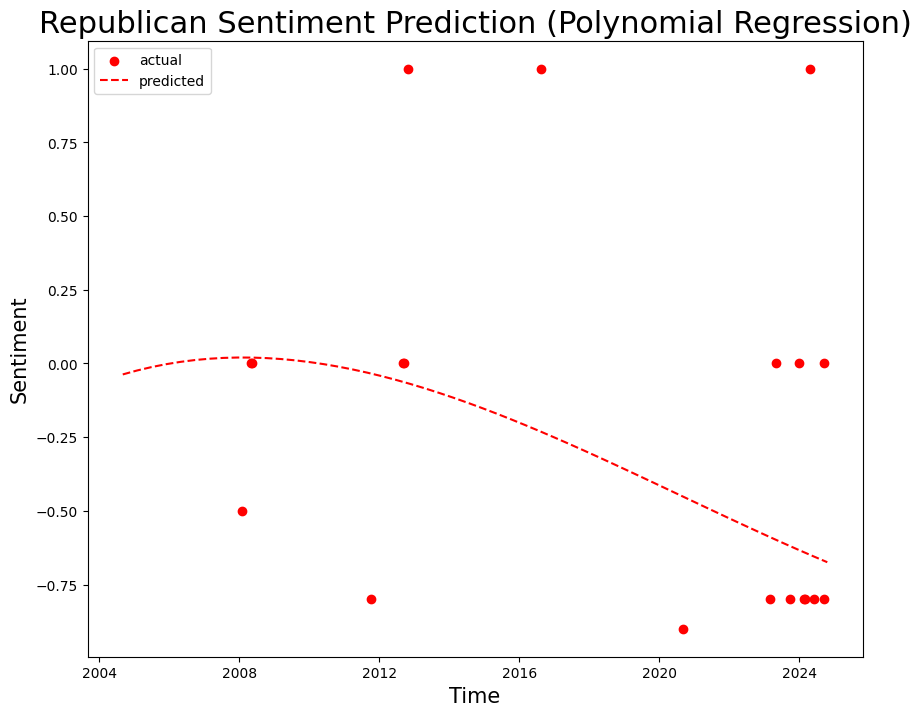

In [56]:
# plot the models

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.scatter(y=test_R["Sentiment"], x=test_R.index, c='red', label='actual')
ax.plot([pd.Timedelta(days=day) + train_R.index[0] for day in polyline_R], model_R(polyline_R), color='red', linestyle='dashed', label='predicted')
plt.title(f'Republican Sentiment Prediction (Polynomial Regression)', fontsize=22)
plt.xlabel('Time', fontsize=15)
plt.ylabel('Sentiment', fontsize=15)
plt.legend()

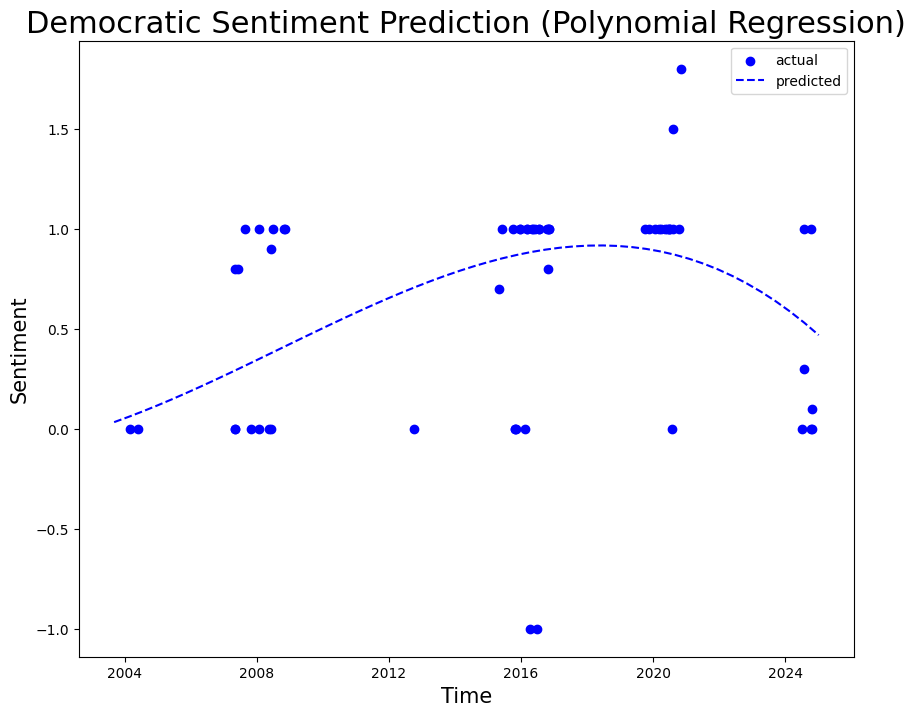

In [57]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.scatter(y=test_D["Sentiment"], x=test_D.index, c='blue', label='actual')
ax.plot([pd.Timedelta(days=day) + train_D.index[0] for day in polyline_D], model_D(polyline_D), color='blue', linestyle='dashed', label='predicted')
plt.title(f'Democratic Sentiment Prediction (Polynomial Regression)', fontsize=22)
plt.xlabel('Time', fontsize=15)
plt.ylabel('Sentiment', fontsize=15)
plt.legend()

In [53]:
print(model_D)
print(model_R)

            3             2
-5.842e-12 x + 3.215e-08 x + 0.0001604 x + 0.03273
           3             2
2.453e-12 x - 4.284e-08 x + 9.574e-05 x - 0.0373


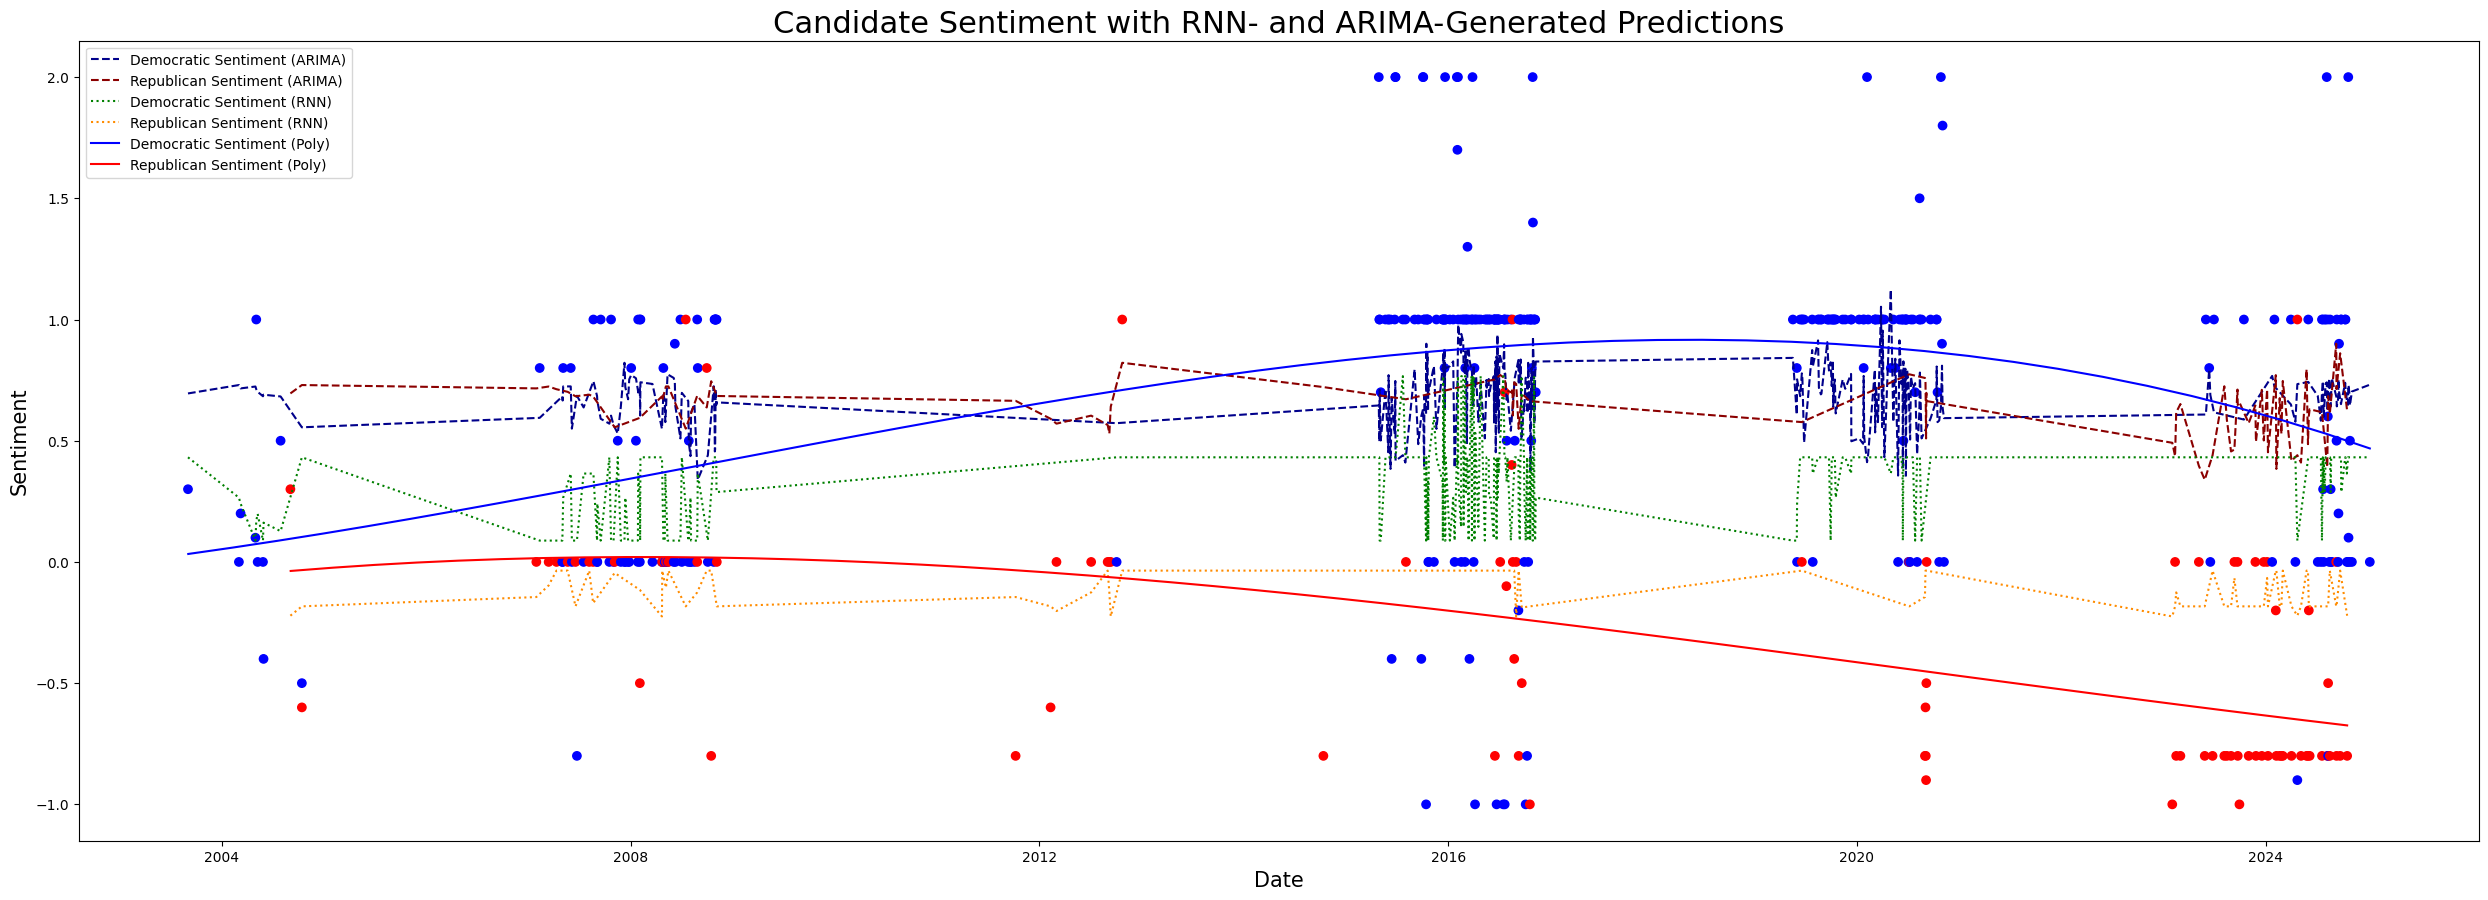

In [58]:
# make a scatterplot from the sentiments and add a line for the predictions
# results may vary

fig = plt.figure(figsize=(24, 8))
h = [Size.Fixed(1.0), Size.Fixed(4.5)]
v = [Size.Fixed(0.7), Size.Fixed(5.)]
divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
ax = fig.add_axes(divider.get_position())
ax.scatter(y=time_series["Sentiment"], x=time_series["Date"], c=time_series["Color"])
ax.plot(time_series[time_series['Party']=='DEMOCRAT']['Date'], predict_D_ARIMA, color="darkblue", linestyle='dashed', label="Democratic Sentiment (ARIMA)")
ax.plot(time_series[time_series['Party']=='REPUBLICAN']['Date'], predict_R_ARIMA, color="darkred",linestyle='dashed', label="Republican Sentiment (ARIMA)")
ax.plot(time_series[time_series['Party']=='DEMOCRAT']['Date'], predict_D_RNN, color="green", linestyle='dotted', label="Democratic Sentiment (RNN)")
ax.plot(time_series[time_series['Party']=='REPUBLICAN']['Date'], predict_R_RNN, color="darkorange", linestyle='dotted', label="Republican Sentiment (RNN)")
ax.plot([pd.Timedelta(days=day) + train_D.index[0] for day in polyline_D], model_D(polyline_D), color='blue', label="Democratic Sentiment (Poly)")
ax.plot([pd.Timedelta(days=day) + train_R.index[0] for day in polyline_R], model_R(polyline_R), color='red', label="Republican Sentiment (Poly)")
plt.xlabel('Date', fontsize=15)
plt.ylabel('Sentiment', fontsize=15)
plt.title("Candidate Sentiment with RNN- and ARIMA-Generated Predictions",  fontsize=22)
plt.legend()
#plt.savefig("model.png")
#plt.close()